In [ ]:
!pip install optuna

[I 2025-04-30 11:38:21,011] A new study created in memory with name: no-name-a6f07da5-aebc-4cd2-8144-02720e6b0379


Starting trial 0 with parameters: {'num_conv_layers': 1, 'num_filters_base': 16, 'kernel_size': 3, 'dropout_rate': 0.2322407929200383, 'num_fc_units': 128, 'learning_rate': 0.0032061012528933337, 'optimizer': 'SGD'}
Epoch [1], Batch [50], Loss: 2.2139
Epoch [1], Batch [100], Loss: 2.0355
Epoch [1], Batch [150], Loss: 1.9351
Epoch [1], Batch [200], Loss: 1.8609
Epoch [1], Batch [250], Loss: 1.8099
Epoch [1], Batch [300], Loss: 1.7689
Epoch [1], Batch [350], Loss: 1.7232
Epoch [1] completed, Average Loss: 1.8856
Epoch [2], Batch [50], Loss: 1.6546
Epoch [2], Batch [100], Loss: 1.6403
Epoch [2], Batch [150], Loss: 1.6194
Epoch [2], Batch [200], Loss: 1.5862
Epoch [2], Batch [250], Loss: 1.5754
Epoch [2], Batch [300], Loss: 1.5255
Epoch [2], Batch [350], Loss: 1.5093
Epoch [2] completed, Average Loss: 1.5765
Epoch [3], Batch [50], Loss: 1.4521
Epoch [3], Batch [100], Loss: 1.4258
Epoch [3], Batch [150], Loss: 1.4381
Epoch [3], Batch [200], Loss: 1.4073
Epoch [3], Batch [250], Loss: 1.3931


[I 2025-04-30 11:39:03,928] Trial 0 finished with value: 53.31 and parameters: {'num_conv_layers': 1, 'num_filters_base': 16, 'kernel_size': 3, 'dropout_rate': 0.2322407929200383, 'num_fc_units': 128, 'learning_rate': 0.0032061012528933337, 'optimizer': 'SGD'}. Best is trial 0 with value: 53.31.


Test Accuracy: 53.31%
Starting trial 1 with parameters: {'num_conv_layers': 2, 'num_filters_base': 16, 'kernel_size': 5, 'dropout_rate': 0.5518553557507353, 'num_fc_units': 512, 'learning_rate': 0.0009261188603095127, 'optimizer': 'Adam'}
Epoch [1], Batch [50], Loss: 1.9996
Epoch [1], Batch [100], Loss: 1.6982
Epoch [1], Batch [150], Loss: 1.5883
Epoch [1], Batch [200], Loss: 1.5169
Epoch [1], Batch [250], Loss: 1.4539
Epoch [1], Batch [300], Loss: 1.4331
Epoch [1], Batch [350], Loss: 1.3851
Epoch [1] completed, Average Loss: 1.5574
Epoch [2], Batch [50], Loss: 1.2917
Epoch [2], Batch [100], Loss: 1.2572
Epoch [2], Batch [150], Loss: 1.2428
Epoch [2], Batch [200], Loss: 1.2154
Epoch [2], Batch [250], Loss: 1.2016
Epoch [2], Batch [300], Loss: 1.1982
Epoch [2], Batch [350], Loss: 1.1629
Epoch [2] completed, Average Loss: 1.2188
Epoch [3], Batch [50], Loss: 1.1055
Epoch [3], Batch [100], Loss: 1.1077
Epoch [3], Batch [150], Loss: 1.0449
Epoch [3], Batch [200], Loss: 1.0700
Epoch [3], Bat

[I 2025-04-30 11:39:44,235] Trial 1 finished with value: 64.53 and parameters: {'num_conv_layers': 2, 'num_filters_base': 16, 'kernel_size': 5, 'dropout_rate': 0.5518553557507353, 'num_fc_units': 512, 'learning_rate': 0.0009261188603095127, 'optimizer': 'Adam'}. Best is trial 1 with value: 64.53.


Test Accuracy: 64.53%
Number of finished trials: 2
Best trial:
  Value: 64.53
  Params: {'num_conv_layers': 2, 'num_filters_base': 16, 'kernel_size': 5, 'dropout_rate': 0.5518553557507353, 'num_fc_units': 512, 'learning_rate': 0.0009261188603095127, 'optimizer': 'Adam'}


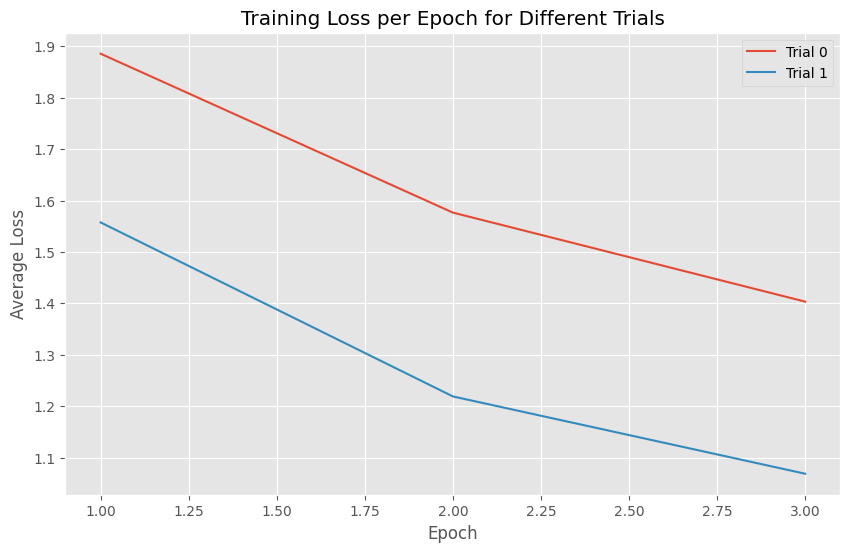

In [ ]:
import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# --- Data Loading ---
def load_cifar10_data(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

    return trainloader, testloader

# --- Model Definition ---
class SimpleCNN(nn.Module):
    def __init__(self, num_conv_layers, num_filters_base, kernel_size, dropout_rate, num_fc_units):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.ModuleList()
        in_channels = 3
        for i in range(num_conv_layers):
            out_channels = num_filters_base * (2**i)
            self.conv_layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=kernel_size//2))
            self.conv_layers.append(nn.ReLU())
            self.conv_layers.append(nn.MaxPool2d(2, 2))
            in_channels = out_channels

        self.dropout = nn.Dropout(dropout_rate)

        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 32, 32)
            for layer in self.conv_layers:
                dummy_input = layer(dummy_input)
            fc_input_size = torch.flatten(dummy_input, 1).shape[1]

        self.fc1 = nn.Linear(fc_input_size, num_fc_units)
        self.fc2 = nn.Linear(num_fc_units, 10)

    def forward(self, x):
        for layer in self.conv_layers:
            x = layer(x)
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# --- Training and Evaluation ---
def train_model(model, train_loader, optimizer, criterion, num_epochs, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    all_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        epoch_losses = []

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            epoch_losses.append(loss.item())

            if i % 50 == 49:
                avg_loss = running_loss / 50
                print(f'Epoch [{epoch + 1}], Batch [{i + 1}], Loss: {avg_loss:.4f}')
                running_loss = 0.0

        avg_epoch_loss = np.mean(epoch_losses)
        all_losses.append(avg_epoch_loss)

    return all_losses

def evaluate_model(model, test_loader, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')
    return accuracy

# --- Optuna Objective Function ---
def objective(trial):
    num_conv_layers = trial.suggest_int('num_conv_layers', 1, 3)
    num_filters_base = trial.suggest_categorical('num_filters_base', [16, 32, 64])
    kernel_size = trial.suggest_categorical('kernel_size', [3, 5])
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.6)
    num_fc_units = trial.suggest_categorical('num_fc_units', [128, 256, 512])
    learning_rate = trial.suggest_float('learning_rate', 5e-4, 5e-3, log=True)
    optimizer_type = trial.suggest_categorical('optimizer', ['Adam', 'SGD'])

    trainloader, testloader = load_cifar10_data()
    model = SimpleCNN(num_conv_layers, num_filters_base, kernel_size, dropout_rate, num_fc_units)
    criterion = nn.CrossEntropyLoss()

    if optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    else:
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=1e-4)

    print(f'Starting trial {trial.number} with parameters: {trial.params}')
    epochs = 10
    losses = train_model(model, trainloader, optimizer, criterion, epochs)

    accuracy = evaluate_model(model, testloader)

    trial.set_user_attr("losses", losses)

    return accuracy

# --- Main Optimization Loop ---
if __name__ == '__main__':
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    print("Number of finished trials: {}".format(len(study.trials)))
    print("Best trial:")
    trial = study.best_trial
    print("  Value: {}".format(trial.value))
    print("  Params: {}".format(trial.params))

    # --- Visualization of Loss ---
    plt.figure(figsize=(10, 6))
    for trial in study.trials:
        if trial.state == optuna.trial.TrialState.COMPLETE and "losses" in trial.user_attrs:
            epochs = range(1, len(trial.user_attrs["losses"]) + 1)
            plt.plot(epochs, trial.user_attrs["losses"], label=f'Trial {trial.number}')

    plt.title('Training Loss per Epoch for Different Trials')
    plt.xlabel('Epoch')
    plt.ylabel('Average Loss')
    plt.legend()
    plt.grid(True)
    plt.show()